# Snake and Ladder — Markov Chain Analysis

**Objective:** find how many turns Snake and Ladder actually takes to finish, and how much each individual snake/ladder reshapes that.
**Method:** the board modeled as an absorbing Markov chain; expected turns via the fundamental matrix, plus board heatmaps, per-element impact, and finish-time distributions.

Reference board layouts used while building the transition matrix are in `../docs/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## STEP 01 - Load the Transition Matrix

In [2]:
N_dices = 1

file_path = f'../data/Markov-Chain - SnL ({N_dices} Dice(s)).xlsx'

df = pd.read_excel(file_path, sheet_name='matrix', header=None, index_col=None)
df = df.iloc[1:, 1:]

transition_matrix = df.to_numpy().astype(float)
transition_matrix[transition_matrix < 0] = 0
pd.DataFrame(transition_matrix)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.0,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.000000,0.000000,0.000000,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.166667,0.333333,0.333333,0.166667
96,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
97,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.166667,0.166667,0.166667,0.333333,0.166667
98,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
snake_ladder_df = pd.read_excel(file_path, sheet_name='snake-ladder-setup')
snake_ladder_df

,start,finish,type,Distance,Count
0,3,24,Ladder,21,1
1,8,14,Ladder,6,1
2,13,31,Ladder,18,1
3,33,54,Ladder,21,1
4,39,58,Ladder,19,1
5,41,85,Ladder,44,1
6,69,95,Ladder,26,1
7,79,98,Ladder,19,1
8,89,91,Ladder,2,1
9,25,4,Snake,-21,1


## STEP 02 - Expected Steps to Finish

The fundamental matrix N = (I - Q)^-1, where Q excludes the absorbing (finish) state, gives the expected number of turns from every position.

In [4]:
def analyze_expected_steps(transition_matrix):
    n = transition_matrix.shape[0]
    Q = transition_matrix[:n-1, :n-1]
    I = np.identity(n-1)
    N = np.linalg.inv(I - Q)
    ones = np.ones(n-1)
    expected_steps = np.dot(N, ones)
    return expected_steps

def find_fastest_route(transition_matrix, expected_steps, start_pos=1):
    n = transition_matrix.shape[0]
    current_pos = start_pos
    route = [current_pos]

    while current_pos != n:
        transition_probs = transition_matrix[current_pos-1]
        next_positions = []

        if 1.0 in transition_probs:
            next_pos = np.argmax(transition_probs) + 1
            current_pos = next_pos
            route.append(current_pos)
            continue

        for pos, prob in enumerate(transition_probs):
            if prob > 0:
                next_positions.append((pos+1, expected_steps[pos] if pos < len(expected_steps) else 0))

        if next_positions:
            next_positions.sort(key=lambda x: x[1])
            best_next_pos = next_positions[0][0]
            current_pos = best_next_pos
            route.append(current_pos)
        else:
            break

    return route

def visualize_results(expected_steps, fastest_route, snake_ladder_df):
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(range(1, len(expected_steps)+1)), y=expected_steps)
    plt.title(f'Expected Steps from Each Position (From position 1: {expected_steps[0]:.2f} steps)')
    plt.xlabel('Position')
    plt.ylabel('Expected Steps')
    plt.xticks(range(0, len(expected_steps), 5), range(1, len(expected_steps)+1, 5))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../result/1. expected_steps.png')
    plt.show()

    print("\nFastest Probabilistic Route from Square 1:")
    print(f"Route: {fastest_route}")
    print(f"Number of steps: {len(fastest_route)-1}")

    for i in range(len(fastest_route)-1):
        current = fastest_route[i]
        next_pos = fastest_route[i+1]

        sl_info = snake_ladder_df[(snake_ladder_df['start'] == current)]
        if not sl_info.empty:
            sl_type = sl_info['type'].values[0]
            print(f"Step {i+1}: From square {current} -> {next_pos} ({sl_type})")
        else:
            distance = next_pos - current
            print(f"Step {i+1}: From square {current} -> {next_pos} (Forward {distance} steps)")

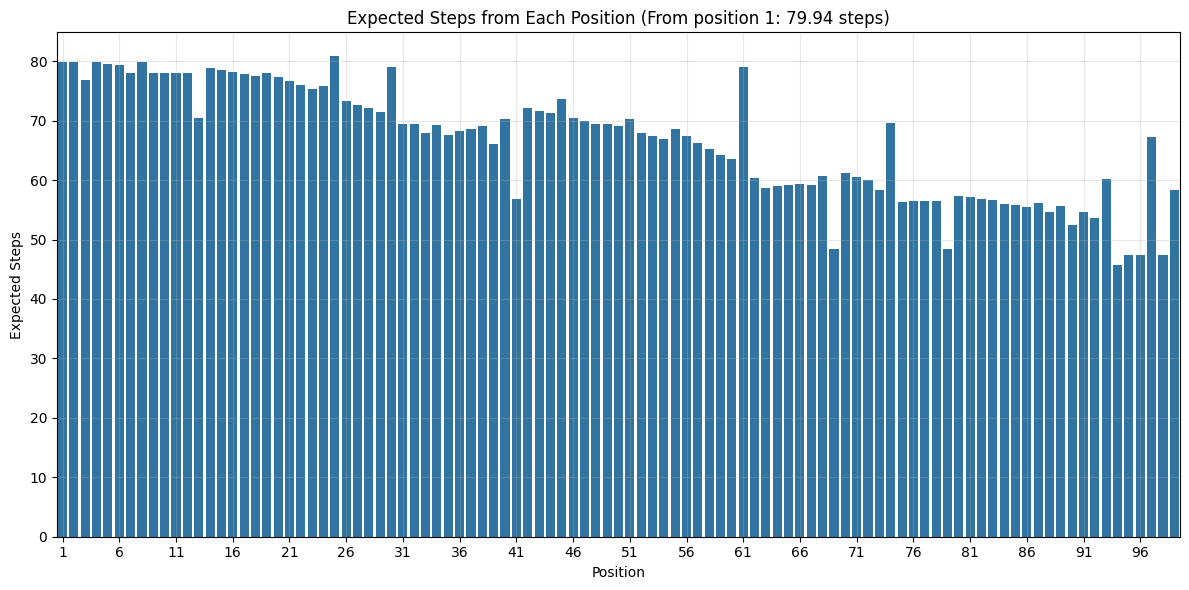


Fastest Probabilistic Route from Square 1:
Route: [1, 3, np.int64(24), 29, 35, 41, np.int64(85), 90, 94, 100]
Number of steps: 9
Step 1: From square 1 -> 3 (Forward 2 steps)
Step 2: From square 3 -> 24 (Ladder)
Step 3: From square 24 -> 29 (Forward 5 steps)
Step 4: From square 29 -> 35 (Forward 6 steps)
Step 5: From square 35 -> 41 (Forward 6 steps)
Step 6: From square 41 -> 85 (Ladder)
Step 7: From square 85 -> 90 (Forward 5 steps)
Step 8: From square 90 -> 94 (Forward 4 steps)
Step 9: From square 94 -> 100 (Forward 6 steps)

From the starting position (square 1), the game takes 79.94 turns on average to finish
Best position: Square 94 (averages 45.65 steps)
Worst position: Square 25 (averages 80.83 steps)


In [5]:
expected_steps = analyze_expected_steps(transition_matrix)
fastest_route = find_fastest_route(transition_matrix, expected_steps)
visualize_results(expected_steps, fastest_route, snake_ladder_df)

print(f"\nFrom the starting position (square 1), the game takes {expected_steps[0]:.2f} turns on average to finish")

best_pos = np.argmin(expected_steps) + 1
worst_pos = np.argmax(expected_steps) + 1
print(f"Best position: Square {best_pos} (averages {expected_steps[best_pos-1]:.2f} steps)")
print(f"Worst position: Square {worst_pos} (averages {expected_steps[worst_pos-1]:.2f} steps)")

## STEP 03 - Board Heatmap Dashboard

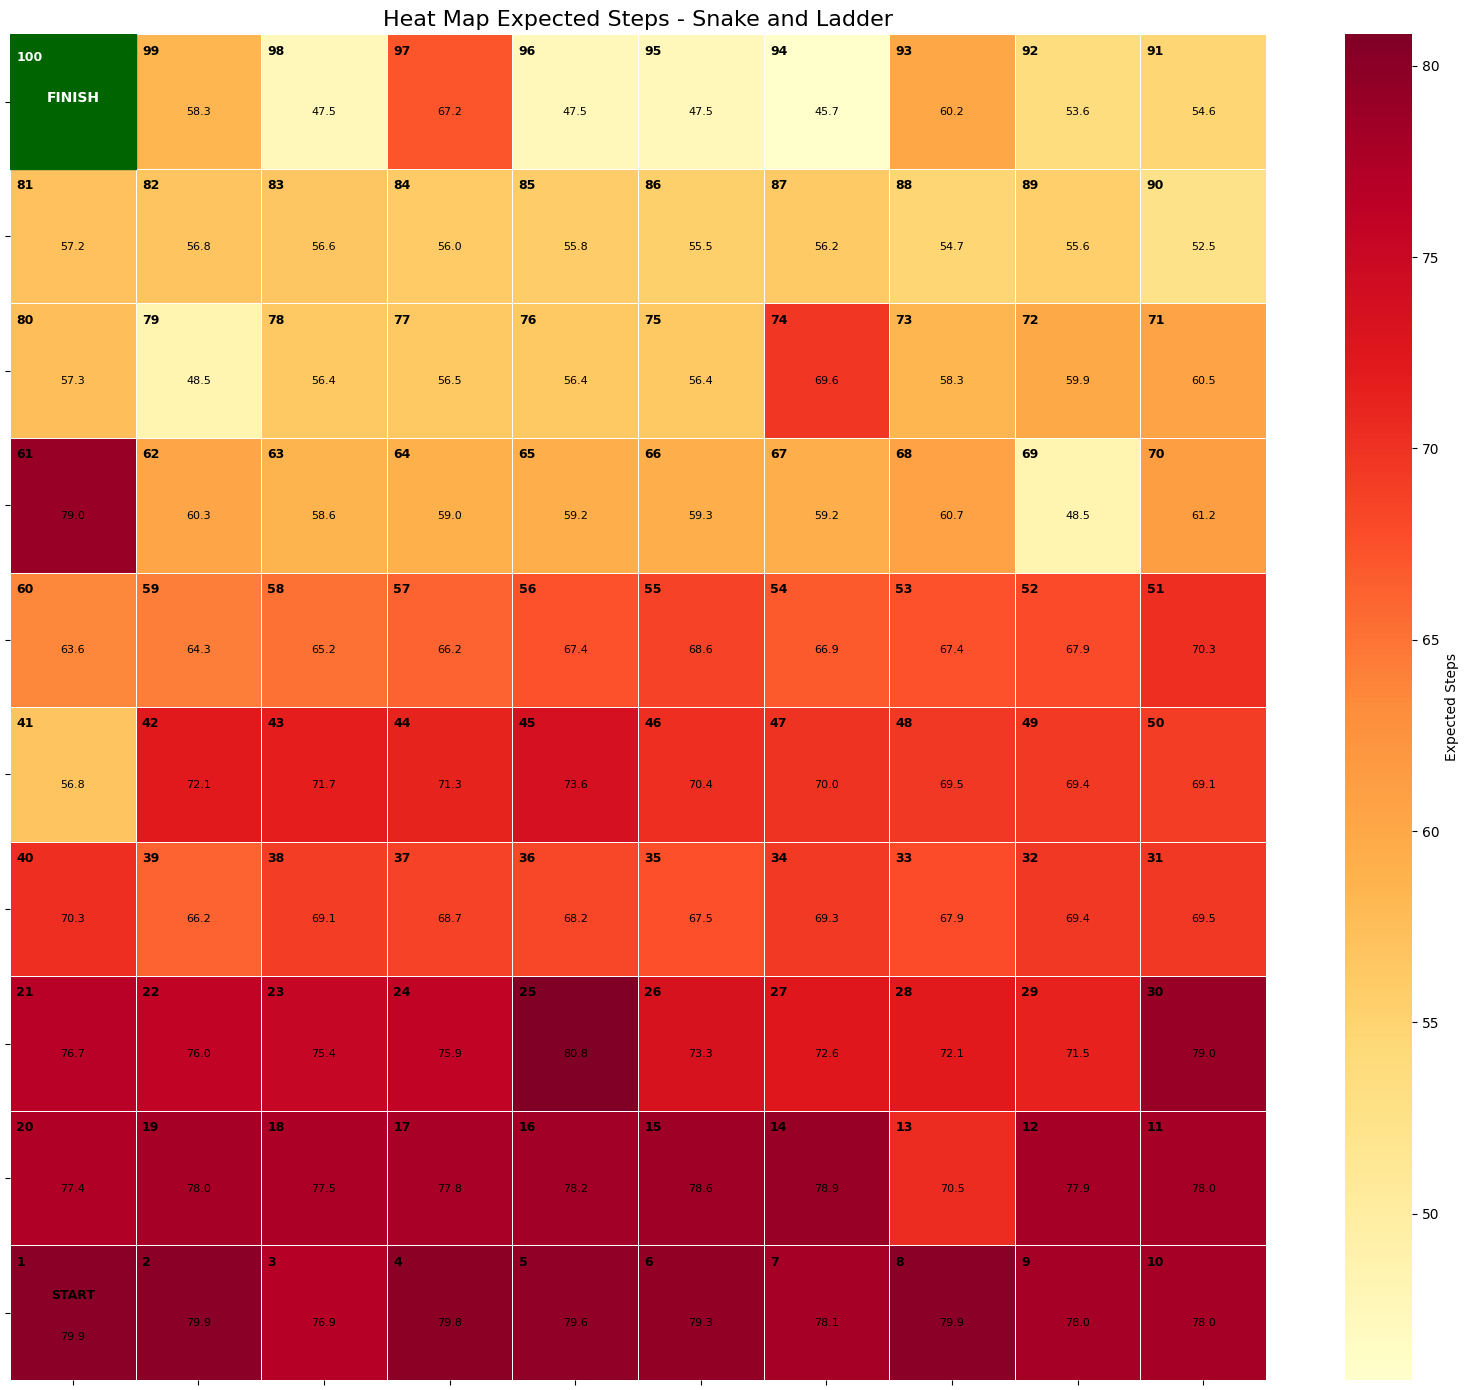

In [6]:
def create_board_heatmap(expected_steps):
    board_data = np.zeros((10, 10))
    values_to_plot = np.append(expected_steps, np.nan)

    for pos in range(1, 101):
        row = (pos - 1) // 10
        if row % 2 == 0:
            col = (pos - 1) % 10
        else:
            col = 9 - ((pos - 1) % 10)
        board_data[9 - row, col] = values_to_plot[pos - 1]

    box_numbers = np.zeros((10, 10), dtype=int)
    for row in range(10):
        for col in range(10):
            if (9-row) % 2 == 0:
                pos = (9-row) * 10 + col
            else:
                pos = (9-row) * 10 + (9 - col)
            box_numbers[row, col] = pos + 1

    plt.figure(figsize=(16, 14))
    mask = np.isnan(board_data)
    min_val = np.nanmin(board_data)
    max_val = np.nanmax(board_data)

    ax = sns.heatmap(board_data, cmap='YlOrRd', annot=False, mask=mask,
                     linewidths=0.5, vmin=min_val, vmax=max_val,
                     cbar_kws={'label': 'Expected Steps'})

    for i in range(10):
        for j in range(10):
            if box_numbers[i][j] == 100:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='darkgreen'))

    for i in range(10):
        for j in range(10):
            box_num = box_numbers[i][j]

            if box_num == 1:
                ax.text(j + 0.05, i + 0.15, f"{box_num}", fontsize=9,
                       fontweight='bold', color='black')
                ax.text(j + 0.5, i + 0.4, "START", fontsize=9,
                       ha='center', color='black', fontweight='bold')
                val = expected_steps[box_num-1]
                ax.text(j + 0.5, i + 0.7, f"{val:.1f}", fontsize=8,
                       ha='center', color='black')
            elif box_num == 100:
                ax.text(j + 0.05, i + 0.2, f"{box_num}", fontsize=9,
                       fontweight='bold', color='white')
                ax.text(j + 0.5, i + 0.5, "FINISH", fontsize=10,
                       ha='center', color='white', fontweight='bold')
            else:
                ax.text(j + 0.05, i + 0.15, f"{box_num}", fontsize=9,
                       fontweight='bold', color='black')
                val = expected_steps[box_num-1]
                ax.text(j + 0.5, i + 0.6, f"{val:.1f}", fontsize=8,
                       ha='center', color='black')

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    plt.title("Heat Map Expected Steps - Snake and Ladder", fontsize=16)
    plt.tight_layout()
    plt.savefig('../result/2. board_heatmap.png', dpi=300)
    plt.show()

create_board_heatmap(expected_steps)

## STEP 04 - Snake and Ladder Impact

For each snake/ladder, compare expected turns from square 1 with vs. without that element (bounce-back rule applied for rolls that would overshoot square 100).

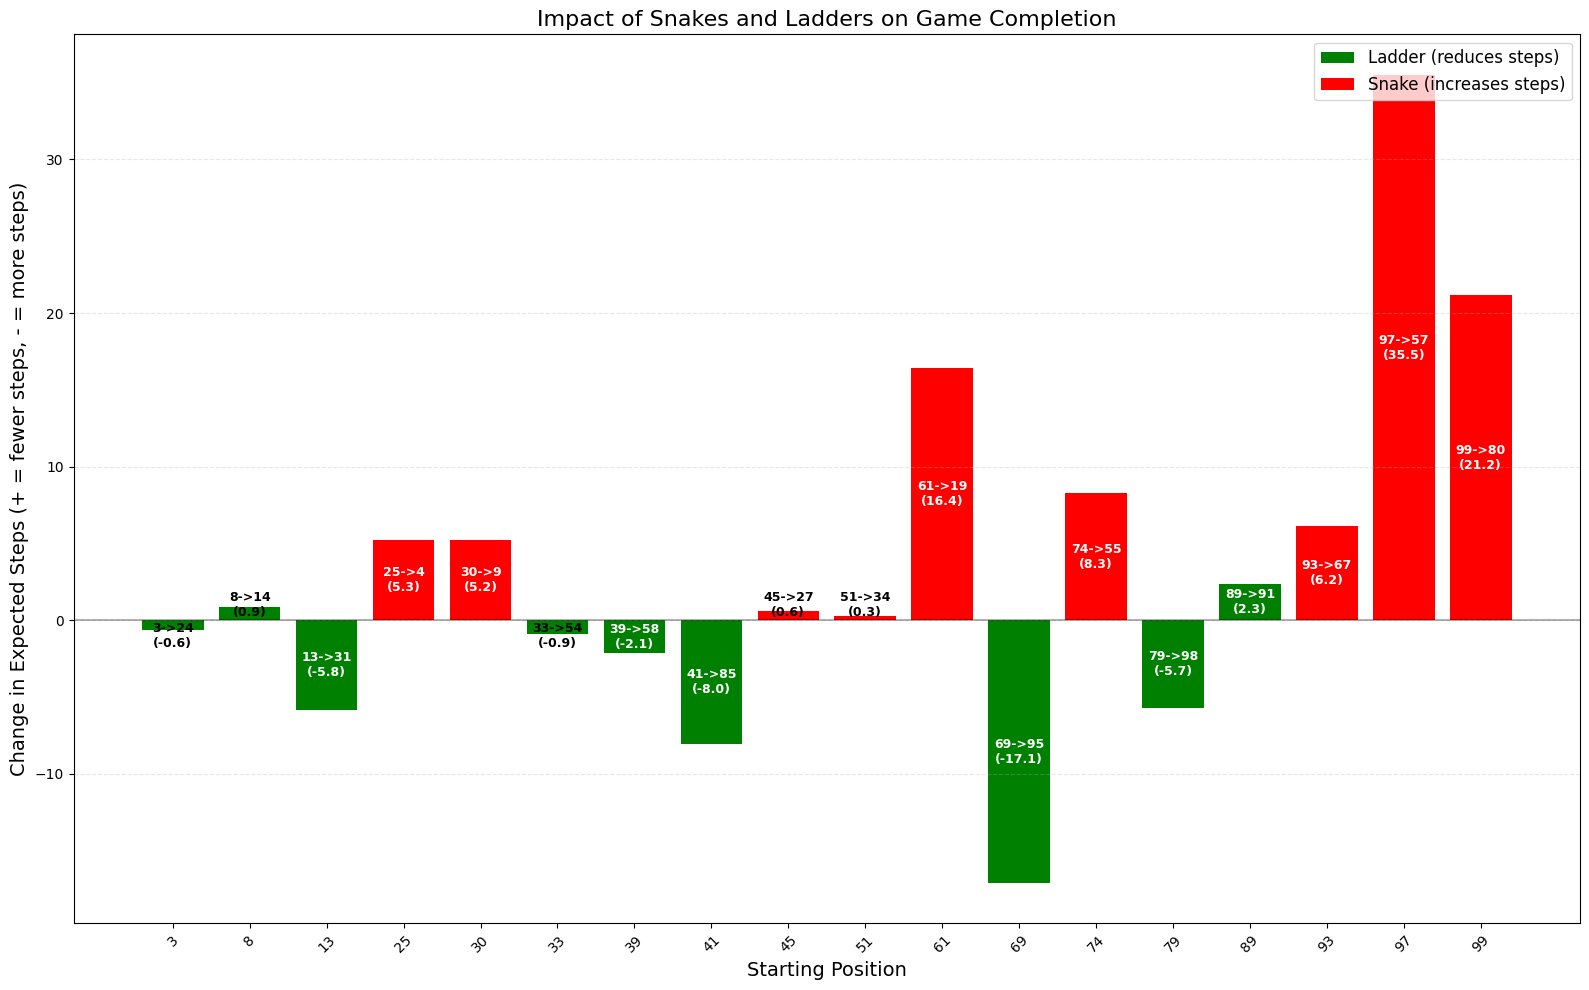

Ladder impact (steps saved):
Total saved: -37.04 steps

Snake impact (steps added):
Total added: 99.00 steps

Net impact: 61.96 steps

Elements with the largest impact:
Snake 97->57: reduces 35.51 steps
Snake 99->80: reduces 21.19 steps
Ladder 69->95: adds 17.09 steps


,Start,End,Type,Impact,Distance,AbsImpact
0,3,24,Ladder,-0.629913,21,0.629913
1,8,14,Ladder,0.877616,6,0.877616
2,13,31,Ladder,-5.809408,18,5.809408
9,25,4,Snake,5.259111,-21,5.259111
10,30,9,Snake,5.231014,-21,5.231014
3,33,54,Ladder,-0.888730,21,0.888730
4,39,58,Ladder,-2.134988,19,2.134988
5,41,85,Ladder,-8.036853,44,8.036853
11,45,27,Snake,0.625937,-18,0.625937
12,51,34,Snake,0.300385,-17,0.300385


In [7]:
def SnL_impact(transition_matrix, snake_ladder_df):
    original_expected = analyze_expected_steps(transition_matrix)[0]
    results = []

    for index, row in snake_ladder_df.iterrows():
        start_pos = int(row['start'])
        end_pos = int(row['finish'])
        element_type = row['type']

        modified_matrix = transition_matrix.copy()
        modified_matrix[start_pos-1] = np.zeros(transition_matrix.shape[1])

        for i in range(1, 7):
            if start_pos + i <= 100:
                modified_matrix[start_pos-1, start_pos+i-1] = 1/6
            else:
                new_pos = 100 - ((start_pos + i) - 100)
                modified_matrix[start_pos-1, new_pos-1] = 1/6

        new_expected = analyze_expected_steps(modified_matrix)[0]
        impact = original_expected - new_expected

        results.append((start_pos, end_pos, element_type, impact, end_pos - start_pos))

    impact_df = pd.DataFrame(results, columns=['Start', 'End', 'Type', 'Impact', 'Distance'])

    plt.figure(figsize=(16, 10))
    colors = {'Snake': 'red', 'Ladder': 'green'}
    impact_df = impact_df.sort_values('Start')

    bars = plt.bar(impact_df['Start'].astype(str), impact_df['Impact'],
                  color=[colors[t] for t in impact_df['Type']])

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    for bar, start, end, impact, distance in zip(bars, impact_df['Start'], impact_df['End'],
                                                impact_df['Impact'], impact_df['Distance']):
        label_text = f"{start}->{end}\n({impact:.1f})"
        y_pos = impact/2
        if abs(impact) < 1:
            y_pos = 1 if impact > 0 else -1
        color = 'white' if abs(impact) > 2 else 'black'
        plt.text(bar.get_x() + bar.get_width()/2, y_pos, label_text,
                ha='center', va='center', color=color, fontweight='bold', fontsize=9)

    plt.title('Impact of Snakes and Ladders on Game Completion', fontsize=16)
    plt.xlabel('Starting Position', fontsize=14)
    plt.ylabel('Change in Expected Steps (+ = fewer steps, - = more steps)', fontsize=14)

    red_patch = plt.Rectangle((0, 0), 1, 1, fc="red")
    green_patch = plt.Rectangle((0, 0), 1, 1, fc="green")
    plt.legend([green_patch, red_patch], ['Ladder (reduces steps)', 'Snake (increases steps)'],
              loc='upper right', fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../result/3. snl_impact.png', dpi=300)
    plt.show()

    print("Ladder impact (steps saved):")
    ladder_impact = impact_df[impact_df['Type'] == 'Ladder']['Impact'].sum()
    print(f"Total saved: {ladder_impact:.2f} steps")

    print("\nSnake impact (steps added):")
    snake_impact = impact_df[impact_df['Type'] == 'Snake']['Impact'].sum()
    print(f"Total added: {snake_impact:.2f} steps")

    print(f"\nNet impact: {ladder_impact + snake_impact:.2f} steps")

    print("\nElements with the largest impact:")
    impact_df['AbsImpact'] = impact_df['Impact'].abs()
    top_impacts = impact_df.sort_values('AbsImpact', ascending=False).head(3)
    for _, row in top_impacts.iterrows():
        element = "Ladder" if row['Type'] == "Ladder" else "Snake"
        effect = "reduces" if row['Impact'] > 0 else "adds"
        steps = abs(row['Impact'])
        print(f"{element} {int(row['Start'])}->{int(row['End'])}: {effect} {steps:.2f} steps")

    return impact_df

SnL_impact(transition_matrix, snake_ladder_df)

## STEP 05 - Position Distribution After N Steps

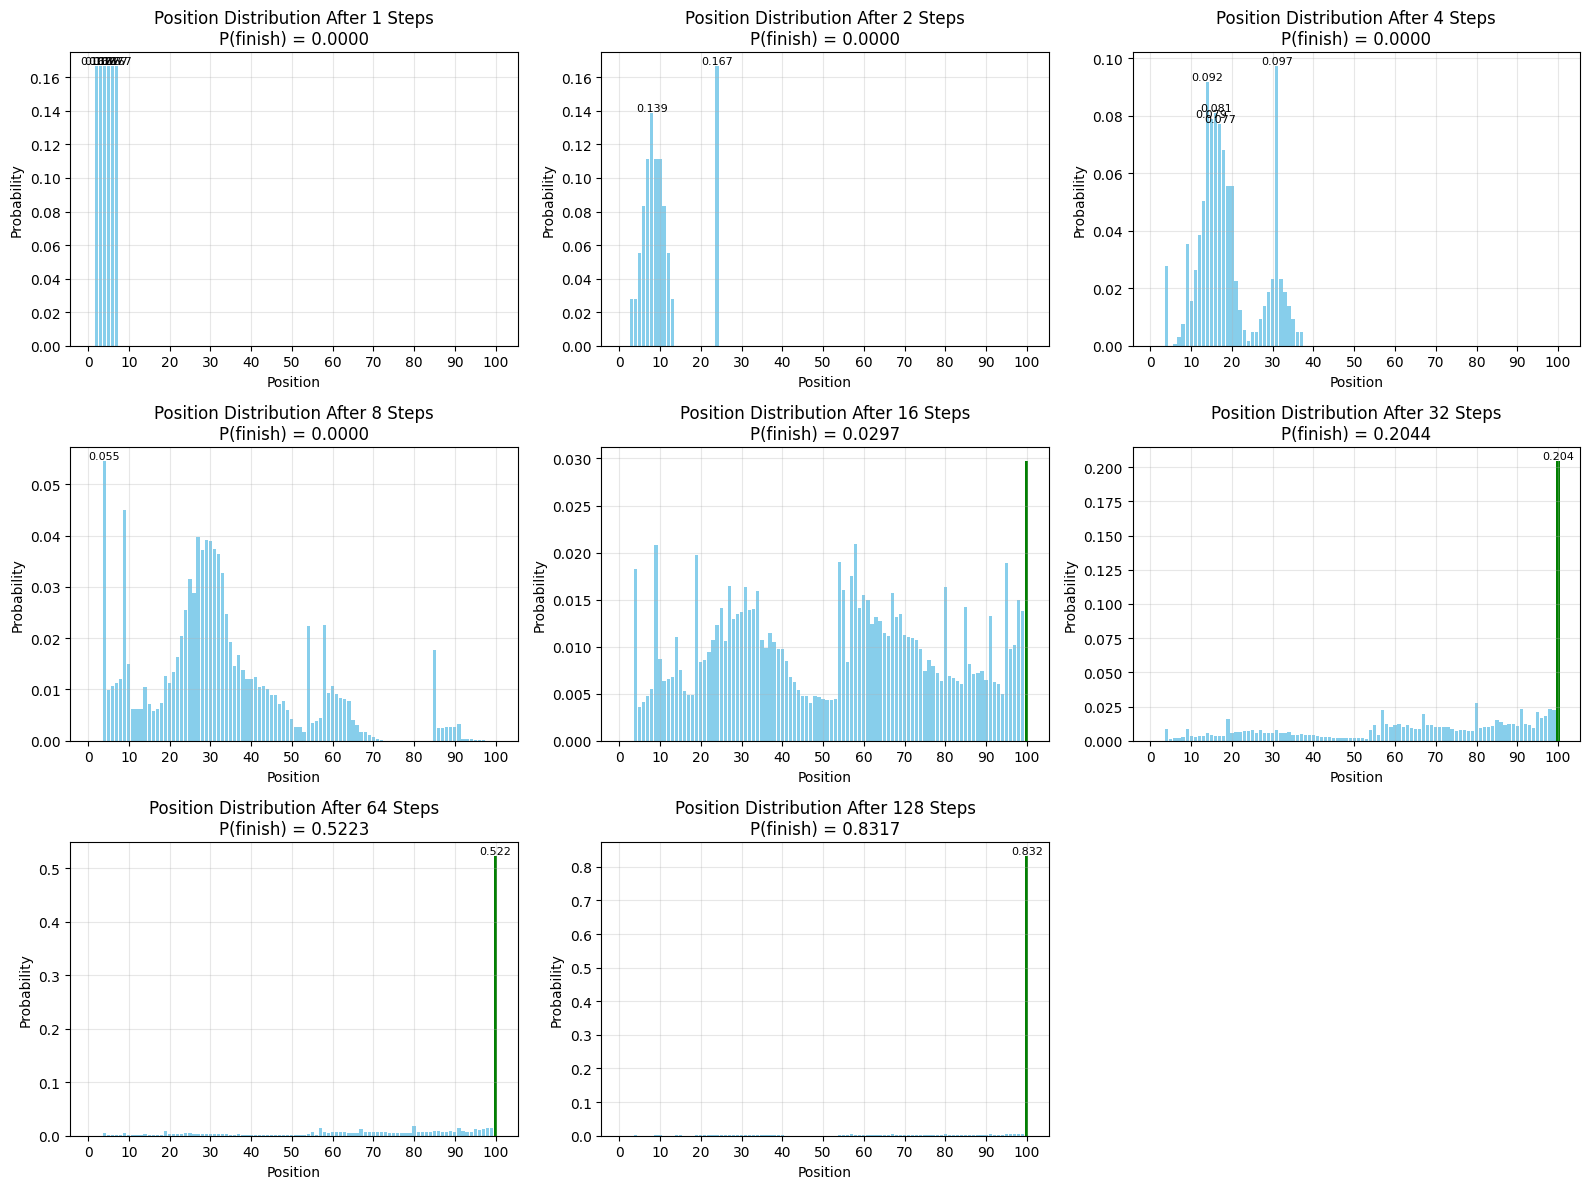

In [8]:
def plot_position_distribution(transition_matrix, steps=[5, 10, 20, 50]):
    n = transition_matrix.shape[0]
    initial_state = np.zeros(n)
    initial_state[0] = 1.0

    num_steps = len(steps)
    nrows = int(np.ceil(num_steps / 3))
    ncols = min(num_steps, 3)

    plt.figure(figsize=(16, 4 * nrows))

    for i, num_steps in enumerate(steps):
        current_state = initial_state.copy()
        for _ in range(num_steps):
            current_state = np.dot(current_state, transition_matrix)

        plt.subplot(nrows, ncols, i+1)
        finish_prob = current_state[-1]

        plt.bar(range(1, n+1), current_state, color='skyblue')
        plt.bar(n, current_state[-1], color='green')

        plt.title(f'Position Distribution After {num_steps} Steps\nP(finish) = {finish_prob:.4f}')
        plt.xlabel('Position')
        plt.ylabel('Probability')

        high_prob_threshold = max(0.05, np.max(current_state) * 0.7)
        for pos, prob in enumerate(current_state):
            if prob > high_prob_threshold:
                plt.annotate(f"{prob:.3f}", xy=(pos+1, prob), ha='center', va='bottom', fontsize=8)

        plt.grid(alpha=0.3)
        plt.xticks(np.arange(0, n+1, 10))

    plt.tight_layout()
    plt.savefig('../result/4. position_distribution.png', dpi=300)
    plt.show()

plot_position_distribution(transition_matrix, steps=[1,2,4,8,16,32,64,128])

## STEP 06 - Finish-Time Distribution

Distribution and cumulative probability of finishing the game at/within a given number of steps.

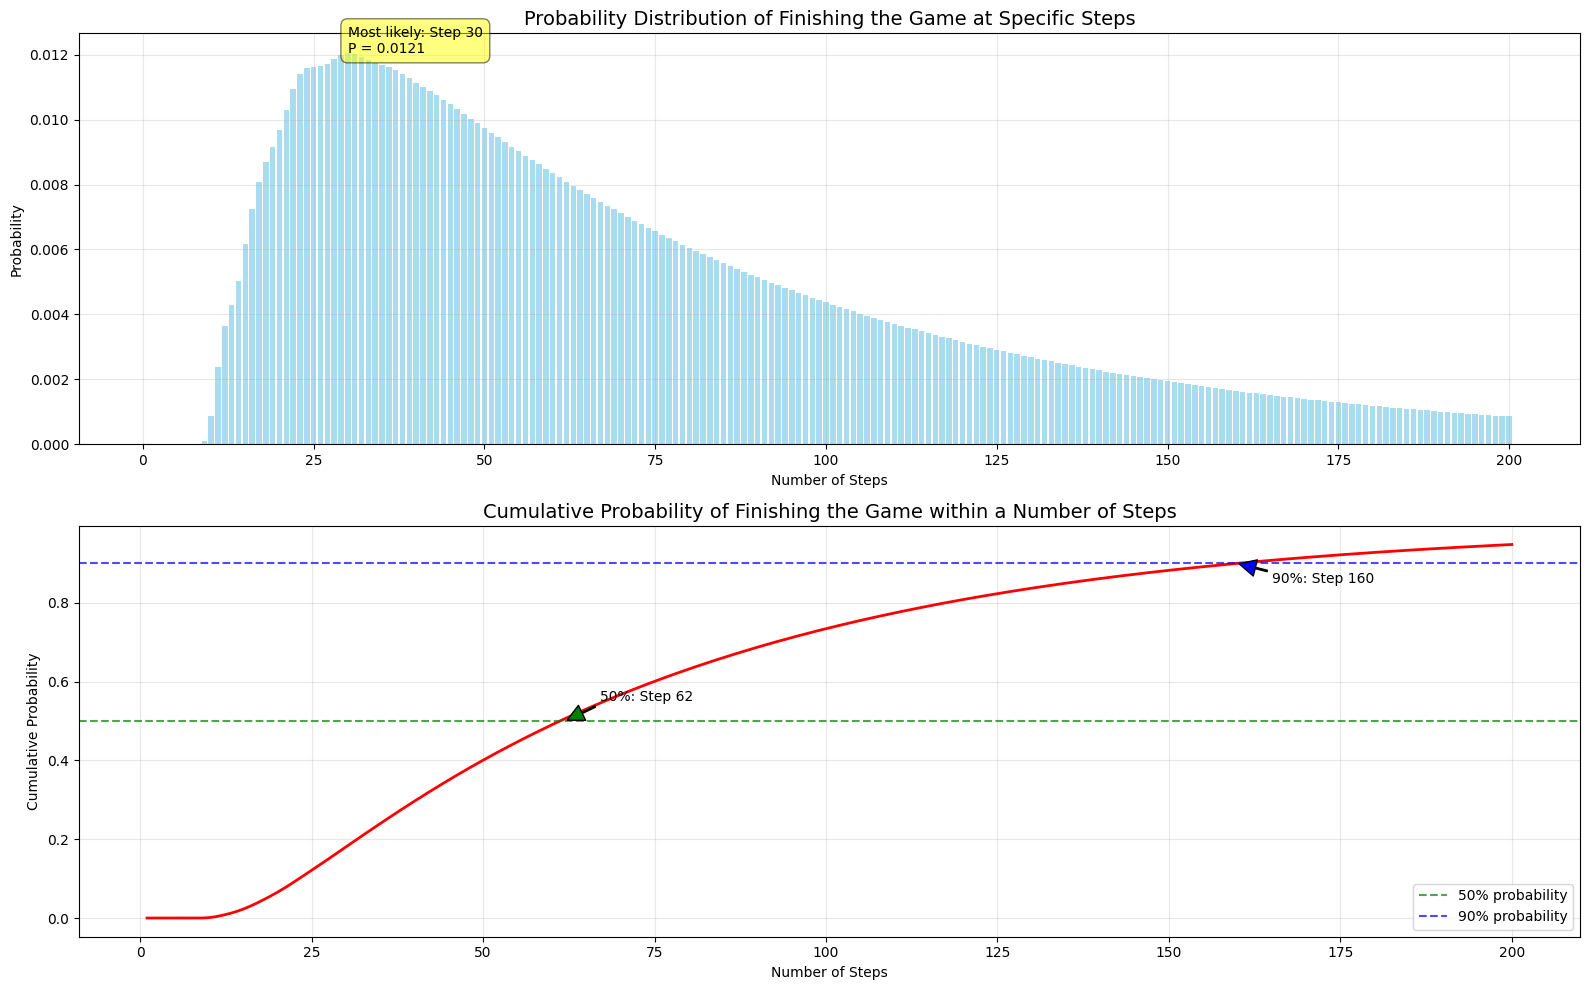


Game Completion Statistics:
----------------------------------------
Step with highest probability: 30 (P = 0.0121)
Median (50% of players finish): 62 steps
Mean (expected steps): 66.32 steps
Standard deviation: 45.37 steps

Completion percentiles:
10%: 24 steps
25%: 36 steps
50%: 62 steps
75%: 104 steps
90%: 160 steps
95%: >200 steps
99%: >200 steps


In [9]:
def plot_finish_probability(transition_matrix, max_steps=200):
    n = transition_matrix.shape[0]
    initial_state = np.zeros(n)
    initial_state[0] = 1.0

    cumulative_probs = []
    current_state = initial_state.copy()

    for _ in range(max_steps):
        current_state = np.dot(current_state, transition_matrix)
        cumulative_probs.append(current_state[-1])

    dist_probs = [cumulative_probs[0]]
    for i in range(1, len(cumulative_probs)):
        dist_probs.append(cumulative_probs[i] - cumulative_probs[i-1])

    plt.figure(figsize=(16, 10))

    plt.subplot(2, 1, 1)
    plt.bar(range(1, max_steps+1), dist_probs, color='skyblue', alpha=0.7)
    plt.title('Probability Distribution of Finishing the Game at Specific Steps', fontsize=14)
    plt.xlabel('Number of Steps')
    plt.ylabel('Probability')
    plt.grid(alpha=0.3)

    max_prob_step = np.argmax(dist_probs) + 1
    max_prob = dist_probs[max_prob_step - 1]

    plt.annotate(f'Most likely: Step {max_prob_step}\nP = {max_prob:.4f}',
                xy=(max_prob_step, max_prob),
                fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.subplot(2, 1, 2)
    plt.plot(range(1, max_steps+1), cumulative_probs, 'r-', linewidth=2)
    plt.axhline(y=0.5, color='g', linestyle='--', alpha=0.7, label='50% probability')
    plt.axhline(y=0.9, color='b', linestyle='--', alpha=0.7, label='90% probability')

    step_50 = next((i for i, p in enumerate(cumulative_probs) if p >= 0.5), None)
    step_90 = next((i for i, p in enumerate(cumulative_probs) if p >= 0.9), None)

    if step_50 is not None:
        step_50 += 1
        plt.annotate(f'50%: Step {step_50}',
                    xy=(step_50, 0.5), xytext=(step_50+5, 0.55),
                    arrowprops=dict(facecolor='green', shrink=0.05, width=1),
                    fontsize=10)

    if step_90 is not None:
        step_90 += 1
        plt.annotate(f'90%: Step {step_90}',
                    xy=(step_90, 0.9), xytext=(step_90+5, 0.85),
                    arrowprops=dict(facecolor='blue', shrink=0.05, width=1),
                    fontsize=10)

    plt.title('Cumulative Probability of Finishing the Game within a Number of Steps', fontsize=14)
    plt.xlabel('Number of Steps')
    plt.ylabel('Cumulative Probability')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig('../result/5. finish_probability_density.png', dpi=300)
    plt.show()

    print("\nGame Completion Statistics:")
    print("-" * 40)
    print(f"Step with highest probability: {max_prob_step} (P = {max_prob:.4f})")

    if step_50 is not None:
        print(f"Median (50% of players finish): {step_50} steps")
    else:
        print(f"Median not reached within {max_steps} steps")

    expected_steps_val = sum((i+1) * prob for i, prob in enumerate(dist_probs))
    print(f"Mean (expected steps): {expected_steps_val:.2f} steps")

    expected_steps_squared = sum(((i+1)**2) * prob for i, prob in enumerate(dist_probs))
    variance = expected_steps_squared - (expected_steps_val**2)
    print(f"Standard deviation: {np.sqrt(variance):.2f} steps")

    percentiles = [10, 25, 50, 75, 90, 95, 99]
    print("\nCompletion percentiles:")

    for p in percentiles:
        threshold = p/100
        step = next((i for i, c in enumerate(cumulative_probs) if c >= threshold), None)
        if step is not None:
            step += 1
            print(f"{p}%: {step} steps")
        else:
            print(f"{p}%: >{max_steps} steps")

plot_finish_probability(transition_matrix, max_steps=200)

## Conclusion

Expected turns from square 1 and the board heatmap show which squares are genuinely lucky or unlucky; the impact chart ranks individual snakes/ladders by how many turns they actually save or cost; the finish-time distribution gives a median and percentile spread instead of a single average.